# IQC and IQC:AIL

## Imports

In [24]:
import qiskit
from qiskit_machine_learning.algorithms import VQC
from qiskit.circuit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, visualize_transition, plot_bloch_vector
from qiskit.circuit.library import UnitaryGate

import numpy as np
from scipy.linalg import expm as expMatrix
from sympy.physics.quantum.dagger import Dagger
import math

from sklearn.model_selection import StratifiedKFold,train_test_split
from sklearn import datasets
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MinMaxScaler
from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import pandas as pd


## Base de Dados

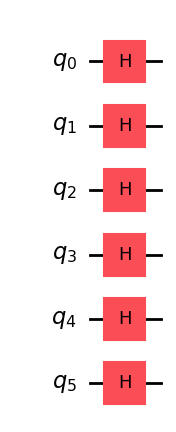

In [27]:
# Criando o circuito
N=30 #Dimensão do vetor de entrada
qc = QuantumCircuit(math.ceil(np.log2(N))+1)
qc.h(0)
qc.h(range(1,math.ceil(np.log2(N))+1))
qc.draw('mpl')


In [29]:
#Printando o circuito
x=np.random.rand(N)
w=np.random.rand(N)

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

sigmaE=np.diag(x)*w.T

#Operador Unitário
#Hint=- hbar*g*np.kron(sigmaQ,sigmaE)
#U=expMatrix(-1j*Hint*(t/hbar))
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

qubits=[i for i in range(math.ceil(np.log2(N))+1)]
qc.unitary(U,qubits)
qc.draw("mpl")

ValueError: Input matrix is not an N-qubit operator.

In [31]:
len(U)

60

In [102]:
# Aqui vamos avaliar o estado depois da evolução 


#Estado completo
sv = Statevector(qc)
sv.draw("latex")

[0, 1, 2]

In [ ]:
# Ao traçar fora o ambiente

rho_res = partial_trace(DensityMatrix.from_instruction(qc), [1]).data
print("Após o traco parcial")

print(rho_res)

In [73]:
#Toy example
x=np.random.rand(2)
w=np.random.rand(2)

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z



sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

sigmaE=np.diag(x)*w.T

#Operador Unitário
#Hint=- hbar*g*np.kron(sigmaQ,sigmaE)
#U=expMatrix(-1j*Hint*(t/hbar))
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))
print(len(U))
print (U@np.ones(len(U)))

4
[[1.03481143+7.37008855e-02j 1.01173956+9.87831702e-01j
  0.96111055+0.00000000e+00j 0.02390786-1.66533454e-16j]]


## IQC

In [3]:
def IQC(x,w):
  n = len(x)

  #from sympy.physics.matrices import msigma(indice)

  #Matrizes de Pauli e a matriz sigma-Q
  matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
  matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
  matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z



  sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

  sigmaE=np.diag(x)*w.T

  #Operador Unitário
  #Hint=- hbar*g*np.kron(sigmaQ,sigmaE)
  #U=expMatrix(-1j*Hint*(t/hbar))
  U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

  def get_p(psi):
    psi=np.matrix(psi)
    return psi*psi.getH()

  #Psis
  #Para os qubits
  psiQ=np.ones((2,1))
  psiQ=(psiQ/np.sqrt(2))

  psiE=np.ones((n,1))
  psiE=(psiE/np.sqrt(n))


  #Rhos
  rhoQ=get_p(psiQ)
  rhoE=get_p(psiE)
  rho_2_systems = np.array(U*(np.kron(rhoQ,rhoE))*Dagger(U))
  #p_cog_new = partial_trace(rho_2_systems, sys=2,dim=[2,n])
  rho_cog_new  = np.trace(rho_2_systems.reshape([2,n,2,n]), axis1=1, axis2=3)
  return rho_cog_new,sigmaE

## IQC:AIL

In [ ]:
def IQC_AIL(x,w):
  n = len(x)
  norma_x=np.linalg.norm(x)+1e-16 #To avoid zero division

  #Matrizes de Pauli e a matriz sigma-Q
  matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
  matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
  matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z



  sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

  sigmaE=np.diag(x)*w.T #No fim, é uma matriz composta apenas por pesos

  #Operador Unitário
  #Hint=- hbar*g*np.kron(sigmaQ,sigmaE)
  #U=expMatrix(-1j*Hint*(t/hbar))
  U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

  def get_p(psi):
    psi=np.matrix(psi)
    return psi*psi.getH()

  #Psis
  #Para os qubits
  psiQ=np.ones((2,1))
  psiQ=(psiQ/np.sqrt(2))

  psiE=np.ones((n,1))
  psiE=(psiE/np.sqrt(n))


  #Rhos
  rhoQ=get_p(psiQ)
  rhoE=get_p(psiE)
  rho_2_systems = np.array(U*(np.kron(rhoQ,rhoE))*Dagger(U))
  #p_cog_new = partial_trace(rho_2_systems, sys=2,dim=[2,n])
  rho_cog_new  = np.trace(rho_2_systems.reshape([2,n,2,n]), axis1=1, axis2=3)
  return rho_cog_new,sigmaE